<a href="https://colab.research.google.com/github/chindarkarsejal800-dot/CSL701-08_Machine-Learning-Lab/blob/main/ML_Experiment_5(new).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name:Sejal Ravindra Chindarkar      RollNo : CS08

### Aim : To implement a Bagging (Bootstrap Aggregating) ensemble classifier from scratch using Python, apply it to the Pima Indians Diabetes Database, and evaluate its performance against a single base classifier (Decision Tree)**.


## Objectives

1. Understand Ensemble Learning Principles: Comprehend how combining the predictions of multiple diverse models reduces overall model variance.
2. Master Bootstrapping: Implement random resampling of data with replacement from scratch to generate distinct training subsets.
3. Develop a Voting System: Build an aggregation mechanism (Majority Voting) from scratch to consolidate predictions.
4. Learn Baseline Evaluation: Compare the performance of a high-variance, low-bias single decision tree against the more stable Bagging ensemble.
5. Analyze Performance Metrics: Calculate and visualize classification metrics, including a Confusion Matrix, Accuracy, Precision, Recall, and ROC-AUC curve.


Relevant Theory
Ensemble Methods and Bagging
Ensemble learning combines several individual classifiers (base learners) to produce a unified model that generalizes better than any single model on unseen data. Bootstrap Aggregating (Bagging) is a parallel ensemble method designed primarily to reduce variance. High-variance models—such as deep, fully-grown decision trees—are highly sensitive to small changes in their training datasets. Bagging addresses this by smoothing out individual model errors without increasing bias.

The two core components of Bagging are:

1. Bootstrapping (Sampling with Replacement): For a training set of size $N$, we generate $B$ new datasets of the same size $N$. Each instance is selected at random from the original dataset with replacement. This means a single instance can be selected multiple times, while on average, only about 63.2% of the unique training samples are captured in each bootstrap, leaving the rest as out-of-bag (OOB) samples.
2. Aggregating (Majority Voting): A separate base learner $h_b(x)$ is trained independently on each bootstrap sample. For classification, predictions are aggregated by passing a test sample to all $B$ models and taking a majority vote: $$\hat{G}{\text{bag}}(x) = \text{argmax}{k} \sum_{b=1}^{B} I(h_b(x) = k)$$

An alternative to standard Bagging is subagging (subsample aggregating), where smaller training subsets (often $N/2$) are drawn without replacement to reduce correlation and accelerate computation.

---
## Software Requirements

- **Language:** Python 3.x

- **Core Libraries:**
  - **NumPy** for matrix manipulation and custom bootstrapping operations.
  - **Pandas** for loading, indexing, and cleaning tabular data.
  - **Matplotlib / Seaborn** for exploratory scatter plots, bar charts, and performance visualization.
  - **Scikit-learn** for train-test splitting, training individual base decision trees, and comparison with built-in Bagging algorithms.

---

## Dataset Information

The experiment utilizes the **Pima Indians Diabetes Database** from the UCI Machine Learning Repository. The dataset contains medical details for 768 female Pima Indian patients living in Arizona, categorized as either diabetic or non-diabetic.

- **Total Instances:** 768

- **Features (8 predictor variables):**
  1. **`Pregnancies`**: Number of times pregnant.
  2. **`Glucose`**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
  3. **`BloodPressure`**: Diastolic blood pressure (mm Hg).
  4. **`SkinThickness`**: Triceps skin fold thickness (mm).
  5. **`Insulin`**: 2-Hour serum insulin ($\mu$U/ml).
  6. **`BMI`**: Body mass index (weight in kg/m$^2$).
  7. **`DiabetesPedigreeFunction`**: A function representing genetic predisposition.
  8. **`Age`**: Age of the subject in years.

- **Target Label (9th column):** **`Outcome`**
  - **0** represents non-diabetic.
  - **1** represents diabetic.

## Experimental Tasks

### Task 1: Environment Setup and Dataset Acquisition

Use dataset using the link  
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

**Goal:** Set up the workspace and load the data.

**Instructions:**

1. Import the necessary modules: **`numpy`**, **`pandas`**, **`matplotlib.pyplot`**, and **`sklearn`**.

2. Load the file **`pima-indians-diabetes.data`** into a Pandas DataFrame, assigning appropriate column headers.

3. Print the following:
   - First five records of the dataset.
   - Dataset shape, expected to be $768 \times 9$.
   - Data types of all features.
   - Descriptive statistics of the numeric features.

In [1]:
# 1. Import necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

# 2. Column names
columns = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age',
    'Outcome'
]

# 3. Load the dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

df = pd.read_csv(url, names=columns)

# 4. Print first five records
print("First five records:")
print(df.head())

# 5. Print dataset shape
print("\nDataset Shape:")
print(df.shape)

# 6. Print data types
print("\nData Types:")
print(df.dtypes)

# 7. Descriptive statistics
print("\nDescriptive Statistics:")
print(df.describe())

First five records:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Shape:
(768, 9)

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    f

## Task 2: Exploratory Data Analysis (EDA)

**Goal:** Visually inspect feature distributions and class balance.

**Instructions:**

1. Calculate the **absolute count** and **percentage** of diabetic (`Outcome = 1`) and non-diabetic (`Outcome = 0`) cases. Plot the class balance using a **bar chart**.

2. Create a **scatter plot** of **`Age`** (Feature 7) against **`Glucose`** (Feature 1), color-coded according to the target variable **`Outcome`**.

3. Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.

Count:
 Outcome
0    500
1    268
Name: count, dtype: int64

Percentage:
 Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


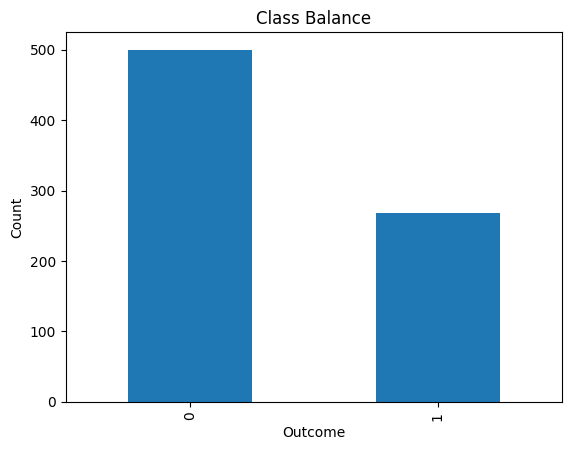

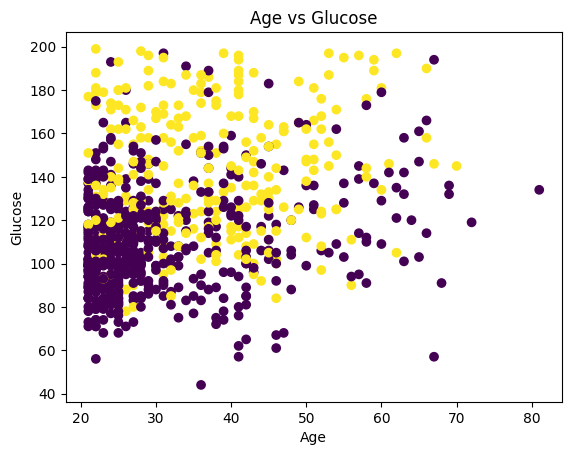

In [11]:
# Class count and percentage
count = df['Outcome'].value_counts()
percent = df['Outcome'].value_counts(normalize=True) * 100

print("Count:\n", count)
print("\nPercentage:\n", percent)

# Bar chart
count.plot(kind='bar')
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.title("Class Balance")
plt.show()

# Scatter plot
plt.scatter(df['Age'], df['Glucose'], c=df['Outcome'])
plt.xlabel("Age")
plt.ylabel("Glucose")
plt.title("Age vs Glucose")
plt.show()

#### **Task 3: Preprocessing and Handling Missing Values**

**Goal:** Handle anomalies and prepare numerical features for further analysis.

**Instructions:**

1. Identify the features where a value of \(0\) is physically impossible:
   \[
   \{\text{Glucose},\text{BloodPressure},\text{SkinThickness},
   \text{Insulin},\text{BMI}\}
   \]

2. Replace all invalid \(0\) values in these features with \(\mathrm{NaN}\).

3. Handle the resulting missing values by:
   - imputing them using the **mean** or **median** of the respective feature, or
   - dropping rows containing missing values to maintain numerical consistency.

In [3]:
import numpy as np

# Features where 0 is invalid
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0 with NaN
df[cols] = df[cols].replace(0, np.nan)

# Fill missing values with median
df[cols] = df[cols].fillna(df[cols].median())

# Check missing values
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


#### **Task 4: Stratified Train-Test Splitting**

**Goal:** Divide the data while preserving class proportions.

**Instructions:**

1. Isolate the feature matrix \(X\) and the target vector \(y\):
   \[
   X = \text{first 8 columns}
   \]
   \[
   y = \text{9th column}
   \]

2. Split the dataset into:
   \[
   \text{Training Data} = 80\%
   \]
   \[
   \text{Test Data} = 20\%
   \]

   Use **stratified sampling** to ensure that the class proportions in the target variable \(y\) are preserved in both the training and test datasets.

In [4]:
from sklearn.model_selection import train_test_split

# Features and target
X = df.iloc[:, :8]
y = df.iloc[:, 8]

# 80% training, 20% testing with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (614, 8)
Testing: (154, 8)


#### **Task 5: Custom Bootstrap Sampling Function**

**Goal:** Implement the sampling-with-replacement mechanism.

**Instructions:**

1. Write a custom Python function \(\texttt{get\_bootstrap\_sample}(X, y)\) using NumPy's random generation tools, such as:
   \[
   \texttt{np.random.choice}
   \quad \text{or} \quad
   \texttt{np.random.randint}
   \]

2. The function must return a resampled feature matrix \(X^*\) and target vector \(y^*\) of the same size \(N\) as the training set:
   \[
   |X^*| = |y^*| = N
   \]
   
   Sampling should be performed **with replacement**, allowing duplicate rows to appear in the bootstrap sample.

3. Verify that the function works correctly by demonstrating that:
   - Some original row indices are **duplicated** in the bootstrap sample.
   - Some original row indices are **omitted**, forming the **Out-of-Bag (OOB)** samples.

In [5]:
import numpy as np

def get_bootstrap_sample(X, y):
    n = len(X)
    indices = np.random.choice(n, size=n, replace=True)
    return X.iloc[indices], y.iloc[indices], indices

# Create bootstrap sample
X_boot, y_boot, indices = get_bootstrap_sample(X_train, y_train)

print("Bootstrap size:", len(X_boot))
print("Sample indices:", indices)

# Duplicated indices
print("Duplicated:", len(indices) - len(set(indices)))

# OOB indices
oob = set(range(len(X_train))) - set(indices)
print("OOB samples:", len(oob))

Bootstrap size: 614
Sample indices: [374 101 482  73 610 356  38 277 231 423 385 203 596 199  99 341 359 257
  72  24 471 134 425 204 332 204 487 463 496 314 480 346 164 391 539 535
 157 510 387 119 330 147 158  25  46 477 339 357 306 479  11 319 307  32
 575 495 576 585 144 467 427 322 612 510 161 579 423 117 145 381 593 357
 549  39 161 372 594 384 382  55 566 293 589 319 229 312 560 165 250  22
 531 122 109 121 189  47 254  79 261 191 516 591 268 375 480 311 274 136
  40  38 364 112 403 455 193 179 364  86 335 349 331 382  66 284 409 524
 136  89 351  19 172  74  72 278 210 511 184  18 476 507 180  44 438 109
  69 414 170  75 523  90  44 261 165 377 295 366  26 536 381  85   0 365
 468 116 453 420 276 183  38 434   3  95 205 536 243 212 155 101 399 195
 378 220 400 233 329 349 486 182  44 536 244 260 265 547 254 233 450 239
 580 130  79 297 201 371  33 564 227  44 314 192 229 481 371 493 533 506
  40 522 378 261 373 215 332 238 345 375 307 461 469 360 232 103 170 400
  26 147   7 51

#### **Task 6: Growing the Ensemble of Base Classifiers**

**Goal:** Programmatically train diverse base learners.

**Instructions:**

1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations, for example:
   \[
   B = 50
   \]

2. Execute the following steps for \(B\) iterations:

   - Generate a unique bootstrap training dataset:
     \[
     (X^{*b}, y^{*b})
     \]
     using the bootstrap sampling function from **Task 5**.

   - Instantiate a Scikit-Learn `DecisionTreeClassifier` with:
     \[
     \texttt{max\_depth=None}
     \]
     This ensures that the decision trees are **fully grown**, resulting in high-variance base learners.

   - Fit the decision tree on the bootstrapped training subset:
     \[
     \text{Model}_b.fit(X^{*b}, y^{*b})
     \]

   - Append the trained model to the ensemble list.

3. After completing all \(B\) iterations, the ensemble should contain:
   \[
   B = 50
   \]
   independently trained decision trees.

In [6]:
from sklearn.tree import DecisionTreeClassifier

B = 50
ensemble = []

for i in range(B):
    X_boot, y_boot, _ = get_bootstrap_sample(X_train, y_train)

    model = DecisionTreeClassifier(max_depth=None)
    model.fit(X_boot, y_boot)

    ensemble.append(model)

print("Number of trees:", len(ensemble))

Number of trees: 50


#### **Task 7: Implementing Aggregation (Majority Voting) from Scratch**

**Goal:** Consolidate individual model decisions using majority voting.

**Instructions:**

1. Write a custom function:
   \[
   \texttt{custom\_bagging\_predict(ensemble, X\_test)}
   \]
   to generate the final predictions.

2. For each sample in \(X_{\text{test}}\), collect the predictions generated by all \(B\) decision trees in the ensemble:
   \[
   \hat{y}_1,\hat{y}_2,\ldots,\hat{y}_B
   \]

3. Apply a **majority voting** rule to determine the final predicted class. The class with the highest number of votes is selected:
   \[
   \hat{y} =
   \underset{c \in \{0,1\}}{\arg\max}
   \sum_{b=1}^{B} I(\hat{y}_b=c)
   \]

   where \(I(\cdot)\) is an indicator function.

4. The final prediction for each test sample must therefore be either:
   \[
   \hat{y} \in \{0,1\}
   \]

5. The function should return the final majority-voted predictions for all samples in \(X_{\text{test}}\).

In [7]:
import numpy as np

def custom_bagging_predict(ensemble, X_test):
    predictions = np.array([model.predict(X_test) for model in ensemble])
    return np.round(predictions.mean(axis=0)).astype(int)

# Final predictions
y_pred = custom_bagging_predict(ensemble, X_test)

print("Predictions:")
print(y_pred)

Predictions:
[1 0 0 0 0 0 0 1 0 1 1 1 0 0 0 0 1 0 1 0 0 1 0 1 0 0 1 0 1 0 0 0 0 0 1 0 0
 0 1 1 0 0 0 0 0 0 0 0 1 0 1 1 0 0 1 0 1 0 1 0 1 0 0 1 0 1 1 0 0 1 0 0 0 1
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 1 1 0 0 0 0 0 1 0 0 0 1 0 0
 1 1 1 0 0 0 0 1 0 1 0 0 1 0 1 1 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1
 0 0 0 0 1 0]


#### **Task 8: Single Classifier vs. Bagging Performance Comparison**

- **Goal:** Observe the variance-reduction benefits of ensembling.

- **Instructions:**
  1. Train a standalone, single \(\texttt{DecisionTreeClassifier}\) (fully grown, no depth limit) on the original, un-resampled training data.
  2. Predict the classes for \(X_{\text{test}}\) using both the single tree and your custom Bagging classifier.
  3. Construct a **Confusion Matrix** for both models.
  4. Compute and print **Accuracy, Precision, Recall, and F1-Score** for both models, demonstrating how Bagging stabilizes results and reduces error rates.

Single Tree Confusion Matrix:
[[78 22]
 [30 24]]

Bagging Confusion Matrix:
[[83 17]
 [23 31]]

Single Tree Accuracy: 0.6623376623376623
Single Tree Precision: 0.5217391304347826
Single Tree Recall: 0.4444444444444444
Single Tree F1: 0.48

Bagging Accuracy: 0.7402597402597403
Bagging Precision: 0.6458333333333334
Bagging Recall: 0.5740740740740741
Bagging F1: 0.6078431372549019


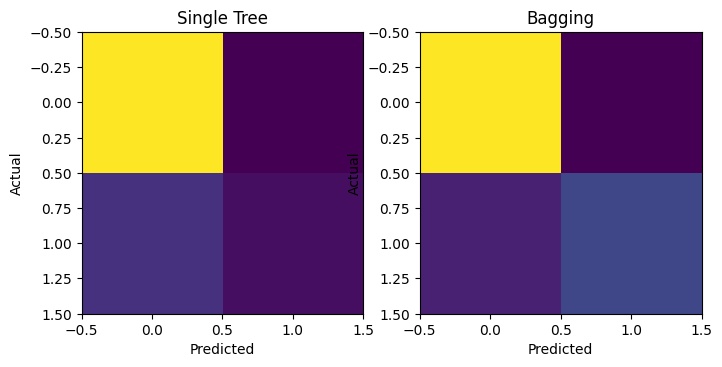

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# Single Decision Tree
tree = DecisionTreeClassifier(max_depth=None)
tree.fit(X_train, y_train)
y_single = tree.predict(X_test)

# Bagging prediction
y_bagging = custom_bagging_predict(ensemble, X_test)

# Confusion matrices
cm_single = confusion_matrix(y_test, y_single)
cm_bagging = confusion_matrix(y_test, y_bagging)

print("Single Tree Confusion Matrix:")
print(cm_single)

print("\nBagging Confusion Matrix:")
print(cm_bagging)

# Metrics
print("\nSingle Tree Accuracy:", accuracy_score(y_test, y_single))
print("Single Tree Precision:", precision_score(y_test, y_single))
print("Single Tree Recall:", recall_score(y_test, y_single))
print("Single Tree F1:", f1_score(y_test, y_single))

print("\nBagging Accuracy:", accuracy_score(y_test, y_bagging))
print("Bagging Precision:", precision_score(y_test, y_bagging))
print("Bagging Recall:", recall_score(y_test, y_bagging))
print("Bagging F1:", f1_score(y_test, y_bagging))

# Display confusion matrices
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].imshow(cm_single)
ax[0].set_title("Single Tree")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")

ax[1].imshow(cm_bagging)
ax[1].set_title("Bagging")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")

plt.show()

#### **Task 9: ROC-AUC Analysis and Curve Visualization**

- **Goal:** Measure classification performance at different thresholds.

- **Instructions:**
  1. Calculate predicted class probabilities by averaging the probability estimates (\(\texttt{predict\_proba}\)) across all \(B\) decision trees in your custom Bagging model.
  2. Plot the **Receiver Operating Characteristic (ROC) curve** for both the single decision tree and the custom Bagging model on a single chart.
  3. Compute and contrast the **Area Under the Curve (AUC)** for both configurations, noting the improvement.

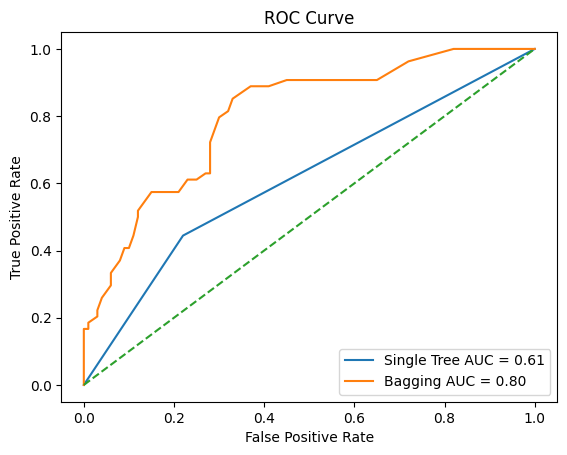

Single Tree AUC: 0.6122222222222222
Bagging AUC: 0.8021296296296296


In [13]:
from sklearn.metrics import roc_curve, roc_auc_score

# Single tree probability
single_prob = tree.predict_proba(X_test)[:, 1]

# Bagging probability
bagging_prob = np.mean(
    [model.predict_proba(X_test)[:, 1] for model in ensemble],
    axis=0
)

# ROC and AUC
fpr1, tpr1, _ = roc_curve(y_test, single_prob)
fpr2, tpr2, _ = roc_curve(y_test, bagging_prob)

auc1 = roc_auc_score(y_test, single_prob)
auc2 = roc_auc_score(y_test, bagging_prob)

# Plot
plt.plot(fpr1, tpr1, label=f"Single Tree AUC = {auc1:.2f}")
plt.plot(fpr2, tpr2, label=f"Bagging AUC = {auc2:.2f}")
plt.plot([0, 1], [0, 1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("Single Tree AUC:", auc1)
print("Bagging AUC:", auc2)

#### **Task 10: Validation against Scikit-Learn's BaggingClassifier**

- **Goal:** Verify custom code correctness.

- **Instructions:**
  1. Instantiate Scikit-Learn's built-in \(\texttt{BaggingClassifier}\) using \(\texttt{DecisionTreeClassifier(max\_depth=None)}\) as the base estimator and \(\texttt{n\_estimators=50}\).
  2. Fit the classifier on the training set and evaluate it on the test set.
  3. Compare the resulting test accuracy and confusion matrix against your custom implementation from **Task 7** and **Task 8** to validate your custom bootstrap and aggregation logic.

Accuracy: 0.7337662337662337

Confusion Matrix:
[[85 15]
 [26 28]]


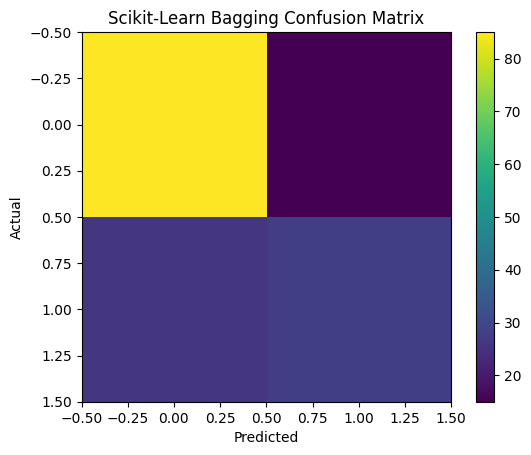

In [14]:
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Create Bagging classifier
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=None),
    n_estimators=50,
    random_state=42
)

# Train
bag.fit(X_train, y_train)

# Predict
y_bag = bag.predict(X_test)

# Results
print("Accuracy:", accuracy_score(y_test, y_bag))

cm = confusion_matrix(y_test, y_bag)
print("\nConfusion Matrix:")
print(cm)

# Display confusion matrix
plt.imshow(cm)
plt.title("Scikit-Learn Bagging Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

### **Conclusion and Interpretation**

Students should summarize their findings by answering the following key questions:

1. **Variance and Stability:** How does the test accuracy of the Bagging ensemble compare to the single decision tree? Why does Bagging provide more consistent performance across different train-test splits?

2. **Wisdom of Crowds:** How does random resampling with replacement (bootstrapping) foster model diversity, and how does the consensus voting rule translate to a "Wisdom of Crowds" effect?

3. **Clinical Interpretation:** In predicting diabetes, why are False Negatives (predicting non-diabetic for a diabetic patient) especially costly, and how does Bagging's Recall metric help minimize this risk compared to a single decision tree?